### Required Assignment 5.1: Will the Customer Accept the Coupon?

**Context**

Imagine driving through town and a coupon is delivered to your cell phone for a restaurant near where you are driving. Would you accept that coupon and take a short detour to the restaurant? Would you accept the coupon but use it on a subsequent trip? Would you ignore the coupon entirely? What if the coupon was for a bar instead of a restaurant? What about a coffee house? Would you accept a bar coupon with a minor passenger in the car? What about if it was just you and your partner in the car? Would weather impact the rate of acceptance? What about the time of day?

Obviously, proximity to the business is a factor on whether the coupon is delivered to the driver or not, but what are the factors that determine whether a driver accepts the coupon once it is delivered to them? How would you determine whether a driver is likely to accept a coupon?

**Overview**

The goal of this project is to use what you know about visualizations and probability distributions to distinguish between customers who accepted a driving coupon versus those that did not.

**Data**

This data comes to us from the UCI Machine Learning repository and was collected via a survey on Amazon Mechanical Turk. The survey describes different driving scenarios including the destination, current time, weather, passenger, etc., and then ask the person whether he will accept the coupon if he is the driver. Answers that the user will drive there ‘right away’ or ‘later before the coupon expires’ are labeled as ‘Y = 1’ and answers ‘no, I do not want the coupon’ are labeled as ‘Y = 0’.  There are five different types of coupons -- less expensive restaurants (under \$20), coffee houses, carry out & take away, bar, and more expensive restaurants (\$20 - $50).

**Deliverables**

Your final product should be a brief report that highlights the differences between customers who did and did not accept the coupons.  To explore the data you will utilize your knowledge of plotting, statistical summaries, and visualization using Python. You will publish your findings in a public facing github repository as your first portfolio piece.





### Data Description
Keep in mind that these values mentioned below are average values.

The attributes of this data set include:
1. User attributes
    -  Gender: male, female
    -  Age: below 21, 21 to 25, 26 to 30, etc.
    -  Marital Status: single, married partner, unmarried partner, or widowed
    -  Number of children: 0, 1, or more than 1
    -  Education: high school, bachelors degree, associates degree, or graduate degree
    -  Occupation: architecture & engineering, business & financial, etc.
    -  Annual income: less than \\$12500, \\$12500 - \\$24999, \\$25000 - \\$37499, etc.
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she buys takeaway food: 0, less than 1, 1 to 3, 4 to 8 or greater
    than 8
    -  Number of times that he/she goes to a coffee house: 0, less than 1, 1 to 3, 4 to 8 or
    greater than 8
    -  Number of times that he/she eats at a restaurant with average expense less than \\$20 per
    person: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    -  Number of times that he/she goes to a bar: 0, less than 1, 1 to 3, 4 to 8 or greater than 8
    

2. Contextual attributes
    - Driving destination: home, work, or no urgent destination
    - Location of user, coupon and destination: we provide a map to show the geographical
    location of the user, destination, and the venue, and we mark the distance between each
    two places with time of driving. The user can see whether the venue is in the same
    direction as the destination.
    - Weather: sunny, rainy, or snowy
    - Temperature: 30F, 55F, or 80F
    - Time: 10AM, 2PM, or 6PM
    - Passenger: alone, partner, kid(s), or friend(s)


3. Coupon attributes
    - time before it expires: 2 hours or one day

In [1]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

### Problems

Use the prompts below to get started with your data analysis.  

1. Read in the `coupons.csv` file.




In [2]:
data = pd.read_csv('data/coupons.csv')

In [3]:
data.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
0,No Urgent Place,Alone,Sunny,55,2PM,Restaurant(<20),1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,1
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,0,0,0,1,0
2,No Urgent Place,Friend(s),Sunny,80,10AM,Carry out & Take away,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,1
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,NaN,4~8,1~3,1,1,0,0,1,0


2. Investigate the dataset for missing or problematic data.

**Step1:** The first step would be to get some information on the data types.

In [4]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12684 entries, 0 to 12683
Data columns (total 26 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   destination           12684 non-null  object
 1   passanger             12684 non-null  object
 2   weather               12684 non-null  object
 3   temperature           12684 non-null  int64 
 4   time                  12684 non-null  object
 5   coupon                12684 non-null  object
 6   expiration            12684 non-null  object
 7   gender                12684 non-null  object
 8   age                   12684 non-null  object
 9   maritalStatus         12684 non-null  object
 10  has_children          12684 non-null  int64 
 11  education             12684 non-null  object
 12  occupation            12684 non-null  object
 13  income                12684 non-null  object
 14  car                   108 non-null    object
 15  Bar                   12577 non-null

**Step2:** Then lets get the statistics for all the columns.


In [5]:
data.describe (include = "all")

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ5min,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
count,12684,12684,12684,12684.000000,12684,12684,12684,12684,12684,12684,...,12467,12533,12554,12495,12684.0,12684.000000,12684.000000,12684.000000,12684.000000,12684.000000
unique,3,4,3,NaN,5,5,2,2,8,5,...,5,5,5,5,NaN,NaN,NaN,NaN,NaN,NaN
top,No Urgent Place,Alone,Sunny,NaN,6PM,Coffee House,1d,Female,21,Married partner,...,less1,1~3,1~3,less1,NaN,NaN,NaN,NaN,NaN,NaN
freq,6283,7305,10069,NaN,3230,3996,7091,6511,2653,5100,...,3385,4672,5376,6077,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,63.301798,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,0.561495,0.119126,0.214759,0.785241,0.568433
std,NaN,NaN,NaN,19.154486,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,0.0,0.496224,0.323950,0.410671,0.410671,0.495314
min,NaN,NaN,NaN,30.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,0.000000,0.000000,0.000000,0.000000,0.000000
25%,NaN,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,0.000000,0.000000,0.000000,1.000000,0.000000
50%,NaN,NaN,NaN,80.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,1.000000,0.000000,0.000000,1.000000,1.000000
75%,NaN,NaN,NaN,80.000000,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,1.0,1.000000,0.000000,0.000000,1.000000,1.000000


**Step3:** How large is the data (Rows & Columns) ?

In [6]:
data.shape

(12684, 26)

**step 4:** Let us get the missing data from the entire data set by column

data.isnull().sum()

**step 5:** How many duplicate rows in the data ?

In [7]:
data.duplicated().sum()

np.int64(74)

**step 6:** Inspect value distributions across all columns

Print a frequency table for every column (with `dropna=False` so missing
values are counted too). This surfaces problematic data at a glance:
missing values, constant columns, redundant fields, and junk or
disguised-numeric entries.

In [8]:
for col in data.columns:
    print(data[col].value_counts(dropna=False), "\n")

destination
No Urgent Place    6283
Home               3237
Work               3164
Name: count, dtype: int64 

passanger
Alone        7305
Friend(s)    3298
Partner      1075
Kid(s)       1006
Name: count, dtype: int64 

weather
Sunny    10069
Snowy     1405
Rainy     1210
Name: count, dtype: int64 

temperature
80    6528
55    3840
30    2316
Name: count, dtype: int64 

time
6PM     3230
7AM     3164
10AM    2275
2PM     2009
10PM    2006
Name: count, dtype: int64 

coupon
Coffee House             3996
Restaurant(<20)          2786
Carry out & Take away    2393
Bar                      2017
Restaurant(20-50)        1492
Name: count, dtype: int64 

expiration
1d    7091
2h    5593
Name: count, dtype: int64 

gender
Female    6511
Male      6173
Name: count, dtype: int64 

age
21         2653
26         2559
31         2039
50plus     1788
36         1319
41         1093
46          686
below21     547
Name: count, dtype: int64 

maritalStatus
Married partner      5100
Single         

3. Decide what to do about your missing data -- drop, replace, other...

**Step1:**  Drop useless columns like `car` column, because 99% of the data is null & the values are garbage.
and Additionally 'toCoupon_GEQ5min' is useless because it is always 1 or 0


In [9]:
data = data.drop(columns=['car'])
data = data.drop(columns=['toCoupon_GEQ5min'])
print("Columns now:", data.shape[1])

Columns now: 24


**Step2:** Merge columns

The variables Bar, CoffeeHouse, CarryAway, RestaurantLessThan20, and Restaurant20To50 contain only a small proportion of missing values (<2% per variable). Given that these fields capture ordinal frequency-based behaviors, missing responses were treated as potentially informative rather than assumed to be missing completely at random. Consequently, an explicit 'unknown' category was introduced, allowing the analysis to retain roughly 600 additional observations and preserve statistical power while maintaining transparency regarding missing data.

In [10]:
dining_habit_columns = [
    'Bar',
    'CoffeeHouse',
    'CarryAway',
    'RestaurantLessThan20',
    'Restaurant20To50'
]
data[dining_habit_columns] = data[dining_habit_columns].fillna('unknown')
data[dining_habit_columns]

,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50
0,never,never,unknown,4~8,1~3
1,never,never,unknown,4~8,1~3
2,never,never,unknown,4~8,1~3
3,never,never,unknown,4~8,1~3
4,never,never,unknown,4~8,1~3
...,...,...,...,...,...
12679,never,never,1~3,4~8,1~3
12680,never,never,1~3,4~8,1~3
12681,never,never,1~3,4~8,1~3
12682,never,never,1~3,4~8,1~3


4. What proportion of the total observations chose to accept the coupon?



The **Y column** tells us the people who accepted the coupon. If data['Y'] =1, then coupon was **accepted**.
The data shows **56.84 % accepted** & **43.16 did not!**

In [11]:
data['Y'].value_counts(normalize=True) * 100

Y
1    56.843267
0    43.156733
Name: proportion, dtype: float64

5. Use a bar plot to visualize the `coupon` column.

There are five distinct dining habit categories, I have used 5 different colors to denote them.

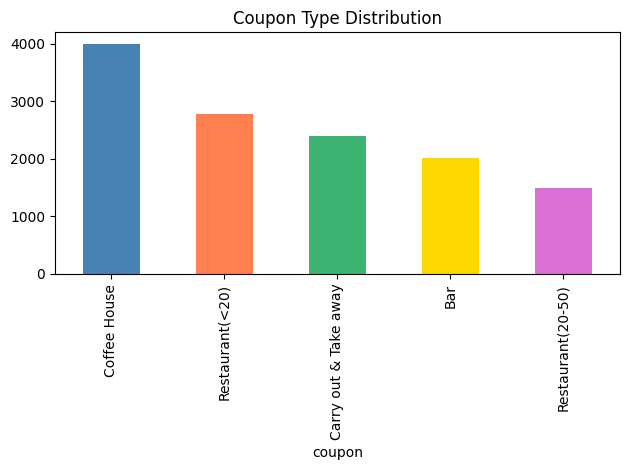

In [12]:
data['coupon'].value_counts().plot(
    kind='bar',
    title='Coupon Type Distribution',
    color=['steelblue', 'coral', 'mediumseagreen', 'gold', 'orchid']
)
plt.tight_layout()
plt.show()

6. Use a histogram to visualize the temperature column.

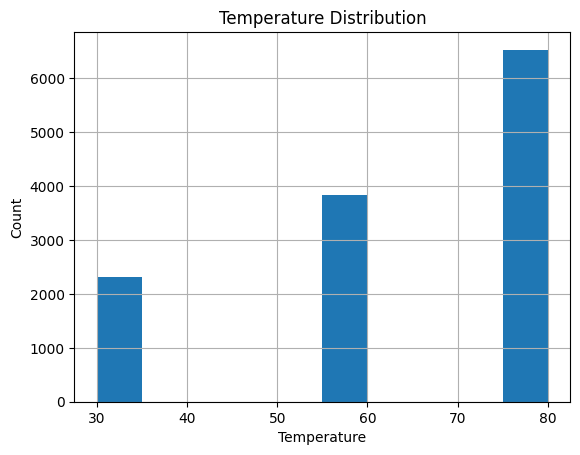

In [13]:
import matplotlib.pyplot as plt
data['temperature'].hist()
plt.xlabel('Temperature')
plt.ylabel('Count')
plt.title('Temperature Distribution')
plt.show()

**Investigating the Bar Coupons**

Now, we will lead you through an exploration of just the bar related coupons.  

1. Create a new `DataFrame` that contains just the bar coupons.


In [14]:
bar = data[data['coupon'] =='Bar']


2. What proportion of bar coupons were accepted?


41 % of the bar coupons were accepted & 59 % of the coupons were never used or refused!

In [15]:
bar['Y'].value_counts(normalize=True) * 100

Y
0    58.998513
1    41.001487
Name: proportion, dtype: float64

3. Compare the acceptance rate between those who went to a bar 3 or fewer times a month to those who went more.


In [16]:
le3 = ['never', 'less1', '1~3']   # 3 or fewer times a month
gt3 = ['4~8', 'gt8']              # more than 3 times a month

rate_le3 = bar[bar['Bar'].isin(le3)]['Y'].mean()
rate_gt3 = bar[bar['Bar'].isin(gt3)]['Y'].mean()

print(f"3 or fewer times/month: {rate_le3*100:.2f}%")
print(f"More than 3 times/month: {rate_gt3*100:.2f}%")

3 or fewer times/month: 37.06%
More than 3 times/month: 76.88%


4. Compare the acceptance rate between drivers who go to a bar more than once a month and are over the age of 25 to the all others.  Is there a difference?


In [17]:
# "more than once a month" = 1~3, 4~8, gt8  (excludes 'never' and 'less1')
freq = ['1~3', '4~8', 'gt8']
# "over 25" -> everyone except the 'below21' and '21' age bands
not_over25 = ['below21', '21']

group = bar[(bar['Bar'].isin(freq)) & (~bar['age'].isin(not_over25))]
others = bar.drop(group.index)

print(f"Bar >1/month AND over 25: {group['Y'].mean()*100:.2f}%")
print(f"All others:               {others['Y'].mean()*100:.2f}%")

Bar >1/month AND over 25: 69.52%
All others:               33.50%


5. Use the same process to compare the acceptance rate between drivers who go to bars more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [18]:
freq = ['1~3', '4~8', 'gt8']   # more than once a month

group = bar[(bar['Bar'].isin(freq)) &
            (bar['passanger'] != 'Kid(s)') &
            (bar['occupation'] != 'Farming Fishing & Forestry')]
others = bar.drop(group.index)

print(f"Frequent bar-goers, no kids, non-farming: {group['Y'].mean()*100:.2f}%")
print(f"All others:                               {others['Y'].mean()*100:.2f}%")

Frequent bar-goers, no kids, non-farming: 71.32%
All others:                               29.60%


6. Compare the acceptance rates between those drivers who:

- go to bars more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to bars more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.



In [19]:
freq       = ['1~3', '4~8', 'gt8']                      # bar > once a month
under30    = ['below21', '21', '26']                    # under age 30
cheap_freq = ['4~8', 'gt8']                             # cheap restaurant > 4x/month
low_income = ['Less than $12500', '$12500 - $24999',
              '$25000 - $37499', '$37500 - $49999']     # income < $50K

cond1 = (bar['Bar'].isin(freq)) & (bar['passanger'] != 'Kid(s)') & (bar['maritalStatus'] != 'Widowed')
cond2 = (bar['Bar'].isin(freq)) & (bar['age'].isin(under30))
cond3 = (bar['RestaurantLessThan20'].isin(cheap_freq)) & (bar['income'].isin(low_income))

group  = bar[cond1 | cond2 | cond3]
others = bar.drop(group.index)

print(f"Combined profile: {group['Y'].mean()*100:.2f}%")
print(f"All others:       {others['Y'].mean()*100:.2f}%")

Combined profile: 58.89%
All others:       29.81%


7.  Based on these observations, what do you hypothesize about drivers who accepted the bar coupons?

### Hypothesis: Who Accepts Bar Coupons?

Drivers who accepted bar coupons were mostly people who **already go to bars regularly**. The biggest factor by far was how often someone visited bars:

- **Frequent bar-goers** (more than once a month) accepted coupons **~70%** of the time
- **Infrequent bar-goers** accepted only **~30%** of the time

Other traits — being over 25, riding with adults instead of kids, or being younger than 30 — lined up with acceptance too, but mainly because those people also tended to be the regular bar-goers.

> **In short:** people accept coupons for places they already like to go.

### Independent Investigation

Using the bar coupon example as motivation, you are to explore one of the other coupon groups and try to determine the characteristics of passengers who accept the coupons.  

I have decided to Investigate the ** Coffee house Coupons** as the next logical step.

Now, lets explore Coffee House Coupons

Create a new DataFrame that contains just the bar coupons.
1. Create a new `DataFrame` that contains just the **Coffee House** Coupons coupons.

In [20]:
coffee_house = data[data['coupon'] =='Coffee House']
coffee_house.head()

,destination,passanger,weather,temperature,time,coupon,expiration,gender,age,maritalStatus,...,Bar,CoffeeHouse,CarryAway,RestaurantLessThan20,Restaurant20To50,toCoupon_GEQ15min,toCoupon_GEQ25min,direction_same,direction_opp,Y
1,No Urgent Place,Friend(s),Sunny,80,10AM,Coffee House,2h,Female,21,Unmarried partner,...,never,never,unknown,4~8,1~3,0,0,0,1,0
3,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,2h,Female,21,Unmarried partner,...,never,never,unknown,4~8,1~3,1,0,0,1,0
4,No Urgent Place,Friend(s),Sunny,80,2PM,Coffee House,1d,Female,21,Unmarried partner,...,never,never,unknown,4~8,1~3,1,0,0,1,0
12,No Urgent Place,Kid(s),Sunny,55,6PM,Coffee House,2h,Female,21,Unmarried partner,...,never,never,unknown,4~8,1~3,1,0,0,1,1
15,Home,Alone,Sunny,80,6PM,Coffee House,2h,Female,21,Unmarried partner,...,never,never,unknown,4~8,1~3,0,0,0,1,0


2. What proportion of Coffee coupons were accepted?

In [21]:
coffee_house['Y'].value_counts(normalize=True) * 100

Y
0    50.075075
1    49.924925
Name: proportion, dtype: float64

3. Compare the acceptance rate between those who went to a restaurant and are less than 20 and 3 or fewer times a month to those who went more.

In [22]:
le3 = ['never', 'less1', '1~3']   # 3 or fewer times a month
gt3 = ['4~8', 'gt8']              # more than 3 times a month

rate_le3 = coffee_house[coffee_house['CoffeeHouse'].isin(le3)]['Y'].mean()
rate_gt3 = coffee_house[coffee_house['CoffeeHouse'].isin(gt3)]['Y'].mean()

print(f"3 or fewer times/month: {rate_le3*100:.2f}%")
print(f"More than 3 times/month: {rate_gt3*100:.2f}%")

3 or fewer times/month: 44.94%
More than 3 times/month: 67.50%


4. Compare the acceptance rate between drivers who go to a coffee house more than once a month and are over the age of 25 to the all others.  Is there a difference?

In [23]:
# "more than once a month" = 1~3, 4~8, gt8  (excludes 'never' and 'less1')
freq = ['1~3', '4~8', 'gt8']
# "over 25" -> everyone except the 'below21' and '21' age bands
not_over25 = ['below21', '21']

group = coffee_house[(coffee_house['CoffeeHouse'].isin(freq)) & (~coffee_house['age'].isin(not_over25))]
others = coffee_house.drop(group.index)

print(f"Coffee house >1/month AND over 25: {group['Y'].mean()*100:.2f}%")
print(f"All others:               {others['Y'].mean()*100:.2f}%")

Coffee house >1/month AND over 25: 63.84%
All others:               42.76%


5. Use the same process to compare the acceptance rate between drivers who go to coffee house more than once a month and had passengers that were not a kid and had occupations other than farming, fishing, or forestry.


In [24]:
freq = ['1~3', '4~8', 'gt8']   # more than once a month

group = coffee_house[(coffee_house['CoffeeHouse'].isin(freq)) &
            (coffee_house['passanger'] != 'Kid(s)') &
            (coffee_house['occupation'] != 'Farming Fishing & Forestry')]
others = coffee_house.drop(group.index)

print(f"Frequent coffee house-goers, no kids, non-farming: {group['Y'].mean()*100:.2f}%")
print(f"All others:                               {others['Y'].mean()*100:.2f}%")

Frequent coffee house-goers, no kids, non-farming: 66.08%
All others:                               36.51%


6. Compare the acceptance rates between those drivers who:

- go to coffee house more than once a month, had passengers that were not a kid, and were not widowed *OR*
- go to Coffee house more than once a month and are under the age of 30 *OR*
- go to cheap restaurants more than 4 times a month and income is less than 50K.

In [25]:
freq       = ['1~3', '4~8', 'gt8']
under30    = ['below21', '21', '26']
cheap_freq = ['4~8', 'gt8']
low_income = ['Less than $12500', '$12500 - $24999',
              '$25000 - $37499', '$37500 - $49999']

cond1 = (coffee_house['CoffeeHouse'].isin(freq)) & \
        (coffee_house['passanger'] != 'Kid(s)') & \
        (coffee_house['maritalStatus'] != 'Widowed')

cond2 = (coffee_house['CoffeeHouse'].isin(freq)) & \
        (coffee_house['age'].isin(under30))

cond3 = (coffee_house['RestaurantLessThan20'].isin(cheap_freq)) & \
        (coffee_house['income'].isin(low_income))

g1 = coffee_house[cond1]
g2 = coffee_house[cond2]
g3 = coffee_house[cond3]

print(f"Frequent + non-kid + not widowed : {g1['Y'].mean()*100:.2f}% (n={len(g1)})")
print(f"Frequent + under 30              : {g2['Y'].mean()*100:.2f}% (n={len(g2)})")
print(f"Cheap-rest 4+/mo + low income    : {g3['Y'].mean()*100:.2f}% (n={len(g3)})")

Frequent + non-kid + not widowed : 66.08% (n=1813)
Frequent + under 30              : 68.93% (n=985)
Cheap-rest 4+/mo + low income    : 54.30% (n=733)


**Hypothesis on Coffee house:** Coffee house coupon acceptance is driven primarily by the driver's existing coffee house visit frequency. Drivers who already visit at least once a month are substantially more likely to accept, and situational factors — non-kid passengers, being under 30, mid-day timing — further lift acceptance above the ~50% baseline.
The combined-profile result (62.25% vs. 35.79%) supports this: a 26-point gap between drivers who match the profile and those who don't.